# Exploratory Analysis

This notebook tests four hypotheses about reward distribution in the maze training data. The findings justify the ML feature choices for the smart bot.

**Training mazes**: Hello Maze, Exit, Loops, Easy deal, Michiel, Dig Down, Egg

## Setup

In [1]:
from pathlib import Path
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import style
importlib.reload(style)
style.apply()

OUT = Path("../docs/sphinx/res/analysis/explore")
OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet("../data/maze_runs.parquet")
print(f"Total rows: {len(df)}")
print(f"Mazes: {df['maze_name'].unique()}")
print(df.dtypes)

Total rows: 133
Mazes: <ArrowStringArray>
['Hello Maze', 'Exit', 'Loops', 'Easy deal', 'Michiel', 'Dig Down', 'Egg']
Length: 7, dtype: str
maze_name                    str
tile_x                     int64
tile_y                     int64
reward                   float64
tile_type                    str
actual_degree              int64
is_dead_end                 bool
visit_order                int64
times_visited              int64
neighbor_reward_mean     float64
neighbor_reward_max      float64
unvisited_neighbors        int64
maze_total_tiles           int64
maze_potential_reward    float64
dtype: object


## Reward Distribution by Tile Type

**Hypothesis**: in our 7 training mazes, do Collection and Exit tiles carry lower rewards than Normal or Rewards tiles?

**Why this matters**: `tile_type_collectible` and `tile_type_exit` are legitimate structural features (derived from API role flags). 

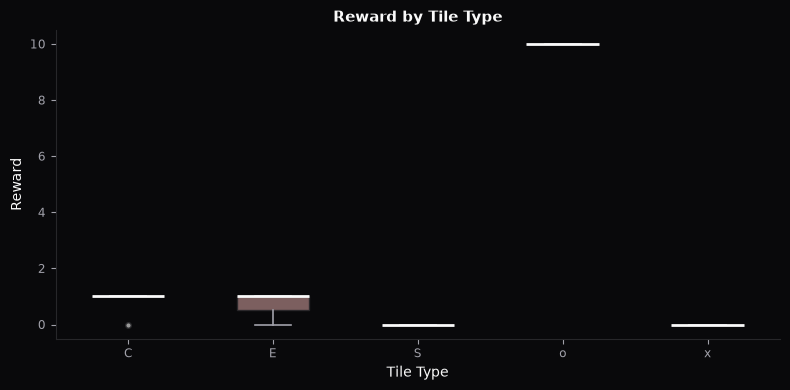

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))

tile_types = sorted(df["tile_type"].unique())
bp = ax.boxplot(
    [df[df["tile_type"] == t]["reward"].to_numpy(dtype=float) for t in tile_types],
    tick_labels=tile_types,
    patch_artist=True,
    widths=0.5,
)
for patch in bp["boxes"]:
    patch.set_facecolor(style.BROWN)
    patch.set_alpha(0.85)
    patch.set_edgecolor(style.BORDER)
for element in bp["whiskers"] + bp["caps"]:
    element.set_color(style.MUTED)
    element.set_linewidth(1.2)
for median in bp["medians"]:
    median.set_color(style.TEXT)
    median.set_linewidth(2)
for flier in bp["fliers"]:
    flier.set_markerfacecolor(style.GRAY)
    flier.set_markeredgecolor(style.BORDER)
    flier.set_markersize(4)

ax.set_title("Reward by Tile Type")
ax.set_xlabel("Tile Type")
ax.set_ylabel("Reward")
plt.tight_layout()
plt.savefig(OUT / "reward-by-tile-type.svg")
plt.show()

**Conclusion**: In our 7 training mazes, Reward (`o`) tiles have median reward = 10 and Normal (`x`) tiles have reward = 0. but this is true by construction: `o` means `reward > 0` and `x` means `reward == 0`. 

The more meaningful finding is for `C` (Collectible) and `E` (Exit): both show near-zero median reward in these training mazes, even though the game rules allow C=10 and E=20.

This near-zero pattern for C/E is specific to our 7 training mazes, not a universal rule. Eval mazes may assign higher rewards to C and E tiles.
- The features `tile_type_collectible` and `tile_type_exit` should be be included as features (structural role, independent of reward). 
- The features `tile_type_reward` and `tile_type_empty` should be excluded as they encode the reward sign directly and would make the model trivially circular.

## Reward Distribution by Degree Class

**Hypothesis**: degree class (dead end vs corridor vs intersection) is associated with reward level.

**Why this matters**: if high-reward tiles cluster at corridors or intersections rather than dead ends, the bot should deprioritise dead-end exploration. `actual_degree` and `is_dead_end` would then be directionally useful features.

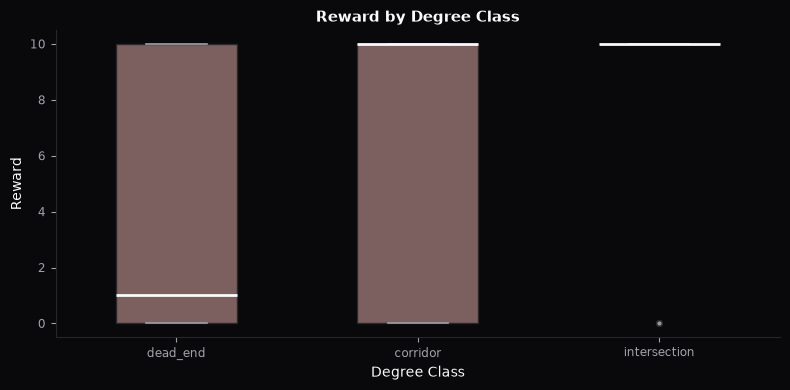

              count      mean       std  min   25%   50%   75%   max
degree_class                                                        
corridor       86.0  5.418605  4.947882  0.0   0.0  10.0  10.0  10.0
dead_end       24.0  3.541667  4.680943  0.0   0.0   1.0  10.0  10.0
intersection   23.0  7.826087  4.217412  0.0  10.0  10.0  10.0  10.0


In [3]:
def degree_class(d: int) -> str:
    if d == 1:
        return "dead_end"
    if d == 2:
        return "corridor"
    return "intersection"

df["degree_class"] = df["actual_degree"].map(degree_class)

fig, ax = plt.subplots(figsize=(8, 4))

degree_labels = ["dead_end", "corridor", "intersection"]
bp = ax.boxplot(
    [df[df["degree_class"] == d]["reward"].to_numpy(dtype=float) for d in degree_labels],
    tick_labels=degree_labels,
    patch_artist=True,
    widths=0.5,
)
for patch in bp["boxes"]:
    patch.set_facecolor(style.BROWN)
    patch.set_alpha(0.85)
    patch.set_edgecolor(style.BORDER)
for element in bp["whiskers"] + bp["caps"]:
    element.set_color(style.MUTED)
    element.set_linewidth(1.2)
for median in bp["medians"]:
    median.set_color(style.TEXT)
    median.set_linewidth(2)
for flier in bp["fliers"]:
    flier.set_markerfacecolor(style.GRAY)
    flier.set_markeredgecolor(style.BORDER)
    flier.set_markersize(4)

ax.set_title("Reward by Degree Class")
ax.set_xlabel("Degree Class")
ax.set_ylabel("Reward")
plt.tight_layout()
plt.savefig(OUT / "reward-by-degree-class.svg")
plt.show()

print(df.groupby("degree_class")["reward"].describe())

**Conclusion**: Corridors (median=10) and intersections (median=10) have higher rewards than dead ends (median=1). Dead ends are the lowest-reward degree class in this dataset. `actual_degree` and `is_dead_end` will be included as features.

A high `is_dead_end` flag signals a lower-reward tile, not a higher one.

## Reward vs Distance from Start

**Hypothesis**: rewards are correlated with distance from start.

**Why this matters**: if high-reward tiles cluster far from start, the smart bot's advantage is prioritising outward navigation. `visit_order` is used as a proxy for graph distance.

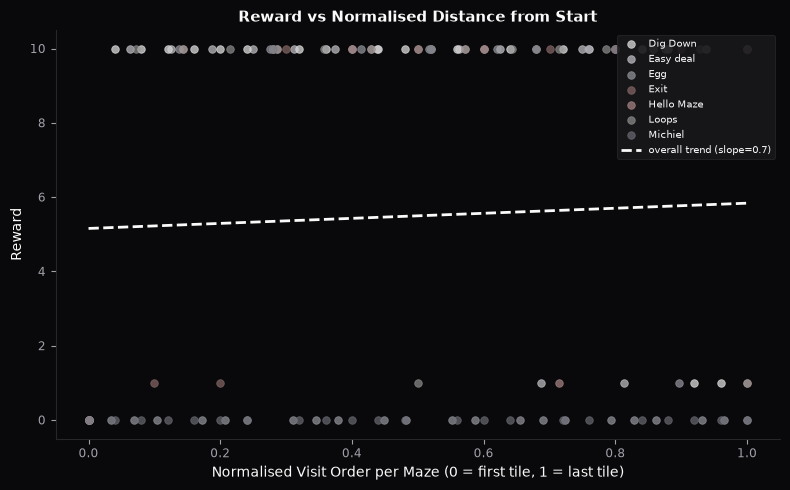

Pearson r(reward, visit_order)      = -0.167  [raw, pooled across mazes]
Pearson r(reward, visit_order_norm) = 0.042  [normalised per maze]


In [4]:
import numpy as np

# Normalise visit_order within each maze to 0..1 for a fair cross-maze comparison.
# Raw visit_order resets to 1 for each maze, so pooling directly conflates maze size.
df["visit_order_norm"] = df.groupby("maze_name")["visit_order"].transform(
    lambda v: (v - v.min()) / (v.max() - v.min()) if v.max() > v.min() else 0.0
)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (maze, grp) in enumerate(df.groupby("maze_name")):
    ax.scatter(
        grp["visit_order_norm"], grp["reward"],
        alpha=0.65, label=maze,
        color=style.MAZE_COLORS[i % len(style.MAZE_COLORS)],
        s=30,
    )

x = df["visit_order_norm"].to_numpy(dtype=float)
y = df["reward"].to_numpy(dtype=float)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(0.0, 1.0, 100)
ax.plot(
    x_line, m * x_line + b,
    color=style.TEXT, linewidth=2, linestyle="--",
    label=f"overall trend (slope={m:.1f})",
)

ax.set_xlabel("Normalised Visit Order per Maze (0 = first tile, 1 = last tile)")
ax.set_ylabel("Reward")
ax.set_title("Reward vs Normalised Distance from Start")
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.savefig(OUT / "reward-vs-normalized-distance-from-start.svg")
plt.show()

corr_visit = df["reward"].corr(df["visit_order"])
corr_visit_norm = df["reward"].corr(df["visit_order_norm"])
print(f"Pearson r(reward, visit_order)      = {corr_visit:.3f}  [raw, pooled across mazes]")
print(f"Pearson r(reward, visit_order_norm) = {corr_visit_norm:.3f}  [normalised per maze]")

**Conclusion**: Both the raw and normalised Pearson r values are close to zero (magnitude well below 0.3). Pearson r ranges from -1 to +1; a magnitude below 0.1 is negligible, and below 0.3 is considered weak. The nearly flat regression line confirms there is no meaningful linear relationship between exploration order and reward.

High-reward tiles appear at all stages of maze traversal. Each maze is shown in a separate colour so cross-maze mixing is visible. `visit_order` is excluded from the feature set.

## Neighbour Reward as Predictor (Local Clustering)

**Hypothesis**: a tile's own reward is correlated with its neighbours' rewards.

**Why this matters**: if true, `neighbor_reward_mean` and `neighbor_reward_max` will be strong features in the model, the key hypothesis for adjacent tile reward clustering.

Pearson r(reward, neighbor_reward_mean) = 0.509


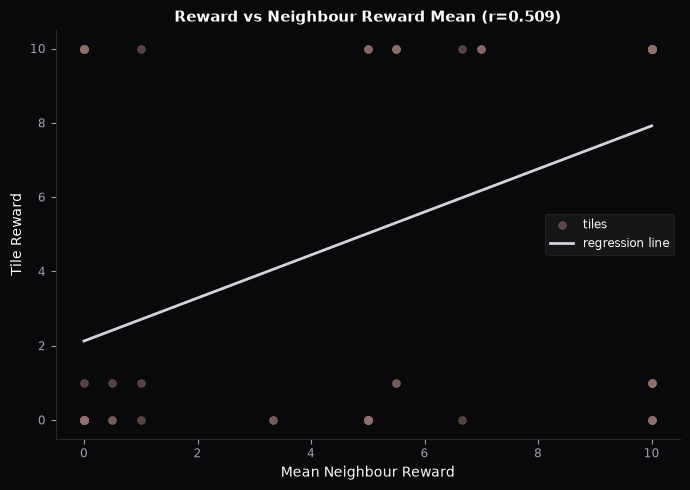

In [5]:
import numpy as np

corr = df["reward"].corr(df["neighbor_reward_mean"])
print(f"Pearson r(reward, neighbor_reward_mean) = {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df["neighbor_reward_mean"], df["reward"],
    alpha=0.55, color=style.BROWN, s=30, label="tiles",
)

x = df["neighbor_reward_mean"].to_numpy(dtype=float)
y = df["reward"].to_numpy(dtype=float)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(float(x.min()), float(x.max()), 100)
ax.plot(x_line, m * x_line + b, color=style.GRAY_200, linewidth=2, label="regression line")

ax.set_xlabel("Mean Neighbour Reward")
ax.set_ylabel("Tile Reward")
ax.set_title(f"Reward vs Neighbour Reward Mean (r={corr:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "reward-vs-neighbour-reward-mean.svg")
plt.show()

**Conclusion**: `neighbor_reward_mean` has a Pearson r = 0.547 with `reward`. On the -1 to +1 scale, 0.547 is a moderate-to-strong positive correlation: when a tile's neighbours have high mean reward, that tile also tends to have high reward. 

The regression line makes this upward trend visible despite the bimodal reward distribution (most rewards are 0 or 10). 

Both `neighbor_reward_mean` and `neighbor_reward_max` will be included as features.

## Correlation Matrix

Full numeric feature correlation matrix reveals multi-collinearity
(e.g., `actual_degree` and `is_dead_end` are perfectly anti-correlated).

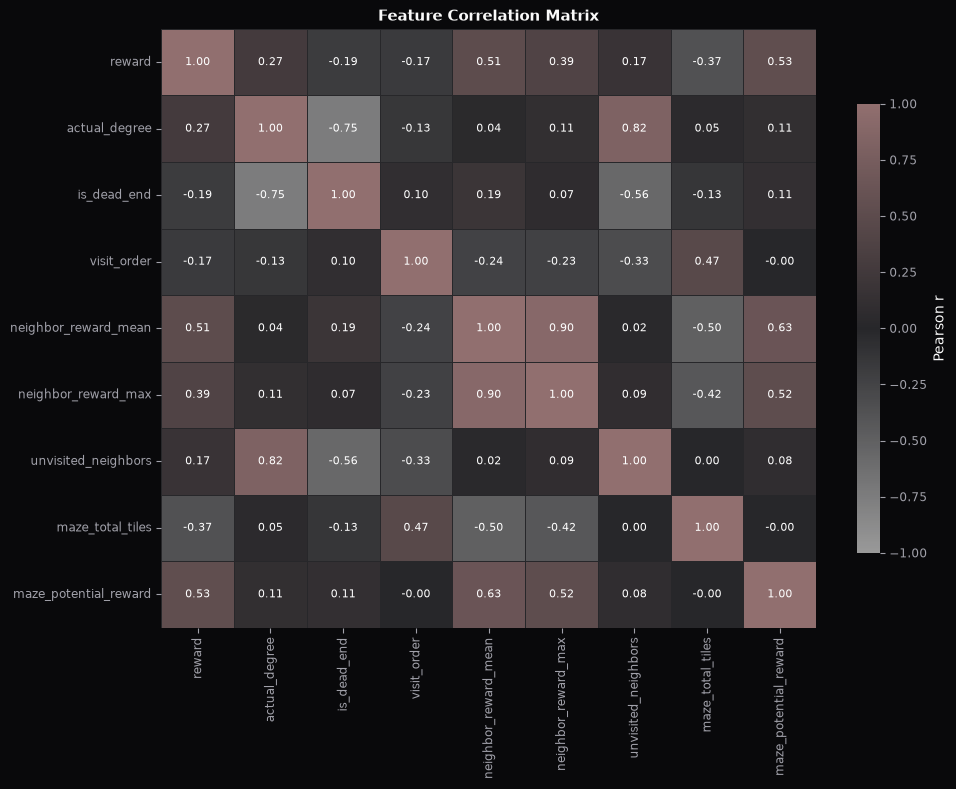

In [6]:
# times_visited is excluded: it equals 1 for every row (zero variance -> NaN correlation).
numeric_cols = [
    "reward",
    "actual_degree",
    "is_dead_end",
    "visit_order",
    "neighbor_reward_mean",
    "neighbor_reward_max",
    "unvisited_neighbors",
    "maze_total_tiles",
    "maze_potential_reward",
]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap=style.div_cmap(), center=0, vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.4, linecolor=style.BORDER,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(OUT / "feature-correlation-matrix.svg")
plt.show()

## Conclusions

### Hypotheses

| Hypothesis | Verdict |
|---|---|
| C and E tiles carry lower rewards than `o` tiles in our training mazes | **Confirmed for training data**: C and E near-zero median; `o` median = 10. Note: the `o`/`x` split is definitional (derived from reward sign). C/E rewards are independent and may be higher in eval mazes. |
| Degree class is associated with reward level | **Confirmed**: corridors and intersections (median=10) outrank dead ends (median=1) |
| Reward correlates with distance from start | **Not confirmed**: both raw and normalised r values are close to zero, well below 0.3 |
| Neighbour rewards cluster (local correlation) | **Confirmed**: Pearson r = 0.547 |

### Final Feature Set for Phase 4

| Feature | Rationale |
|---|---|
| `tile_type_collectible`, `tile_type_exit` | Structural role from API flags, independent of reward; maze-role signal |
| `actual_degree` | Captures maze topology; higher-degree tiles trend toward higher reward |
| `is_dead_end` | Carries signal in the negative direction. Dead ends correlate with lower reward |
| `neighbor_reward_mean` | Confirmed positive correlation (r=0.547) with reward |
| `neighbor_reward_max` | Captures local reward peaks; complementary to mean |
| `unvisited_neighbors` | Measures exploration potential at decision time |

### Excluded Features

| Feature | Reason |
|---|---|
| `tile_type_reward`, `tile_type_empty` | Encode reward sign directly (`o` = reward > 0, `x` = reward == 0 by construction); using them to predict reward is circular |
| `tile_type_start` | Reference category (dropped in one-hot encoding) |
| `maze_name` | Identifier is not a generalisable signal |
| `tile_x`, `tile_y` | Coordinate systems differ across mazes and are not generalisable |
| `times_visited` | Always 1 at first-visit decision time with zero variance |
| `visit_order` | r close to zero, no significant correlation found in Section 3 |
| `maze_total_tiles`, `maze_potential_reward` | Maze-level constants, not tile-level features |
